# Ensemble: Combinación de Modelos A, B y D

Este notebook carga los 4 modelos entrenados de forma individual, construye
el ensemble sin el Modelo C y evalúa múltiples estrategias:

1. **Hard Voting** -- voto mayoritario sobre las etiquetas predichas
2. **Soft Voting** -- promedio de probabilidades predichas
3. **Weighted Voting** -- voto ponderado según el score de validación cruzada
4. **Stacking** -- meta-modelo entrenado sobre predicciones de los modelos base

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

from src.data_loader import load_dataset, get_train_test_split
from src.evaluation import (
    evaluate_model,
    plot_full_evaluation,
    compare_models,
)
from src.model_registry import load_all_models, load_model_metadata

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Cargar Datos y Modelos

In [2]:
df = load_dataset()
X_train, X_test, y_train, y_test = get_train_test_split(df)

Loaded dataset: 5110 rows, 12 columns.
Split: train=4088 rows, test=1022 rows (test_size=0.2, seed=13)


In [3]:
models = load_all_models()
print(f"Modelos cargados: {list(models.keys())}")

Loaded: model_A
Loaded: model_B
Loaded: model_C
Loaded: model_D
Total models loaded: 4
Modelos cargados: ['model_A', 'model_B', 'model_C', 'model_D']


## 2. Rendimiento de Modelos Individuales

Evaluar cada modelo en el conjunto de prueba para tener una línea base de comparación.

=== model_A ===
              precision    recall  f1-score   support

           0       0.98      0.89      0.93       972
           1       0.20      0.56      0.30        50

    accuracy                           0.87      1022
   macro avg       0.59      0.72      0.61      1022
weighted avg       0.94      0.87      0.90      1022



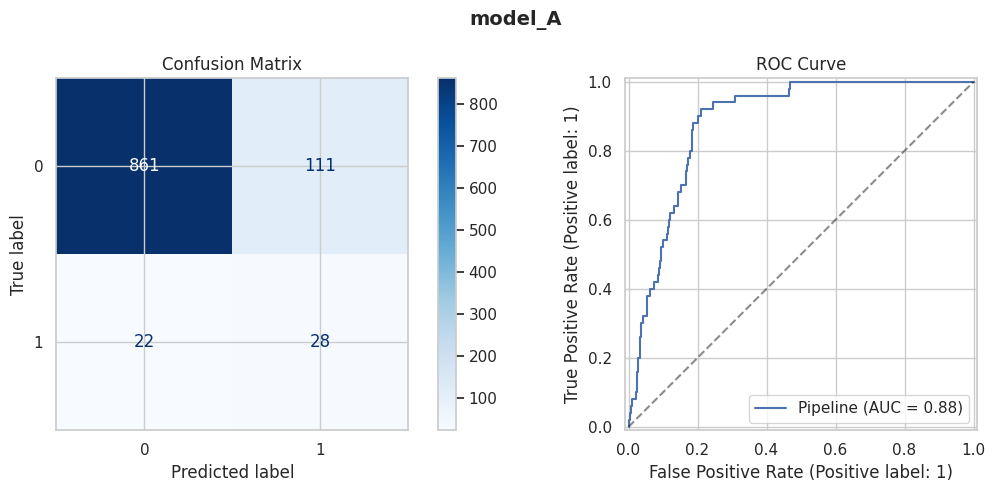

=== model_B ===
              precision    recall  f1-score   support

           0       0.99      0.72      0.84       972
           1       0.14      0.88      0.24        50

    accuracy                           0.73      1022
   macro avg       0.57      0.80      0.54      1022
weighted avg       0.95      0.73      0.81      1022



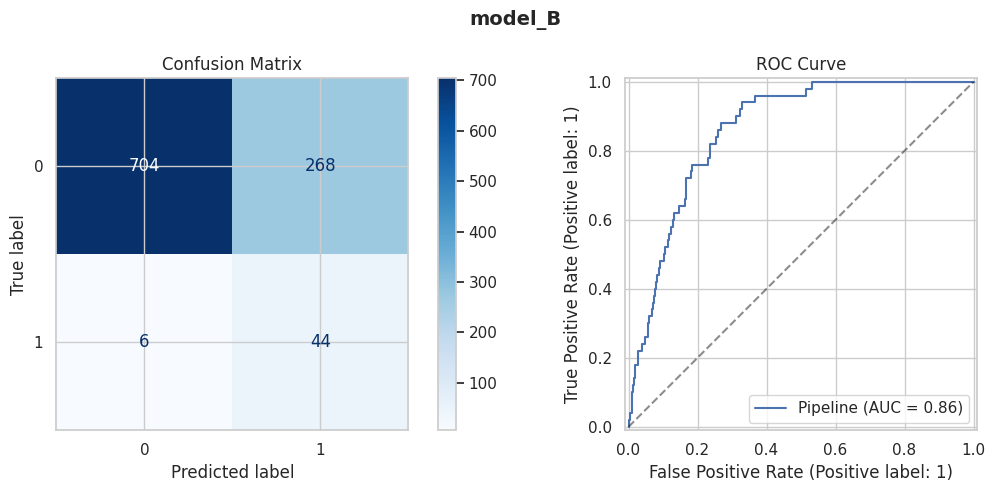

=== model_C ===
              precision    recall  f1-score   support

           0       0.99      0.75      0.85       972
           1       0.15      0.88      0.26        50

    accuracy                           0.76      1022
   macro avg       0.57      0.81      0.56      1022
weighted avg       0.95      0.76      0.82      1022



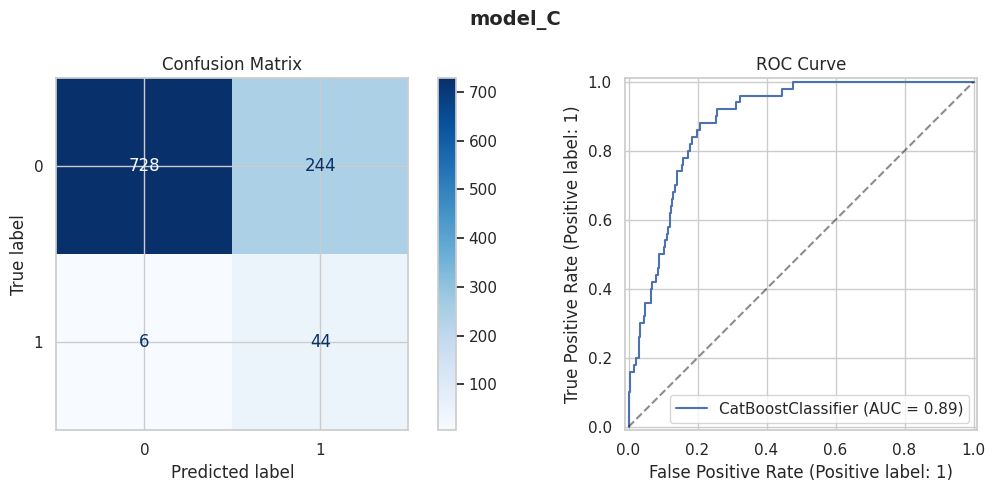

=== model_D ===
              precision    recall  f1-score   support

           0       0.98      0.89      0.93       972
           1       0.21      0.56      0.30        50

    accuracy                           0.87      1022
   macro avg       0.59      0.72      0.62      1022
weighted avg       0.94      0.87      0.90      1022



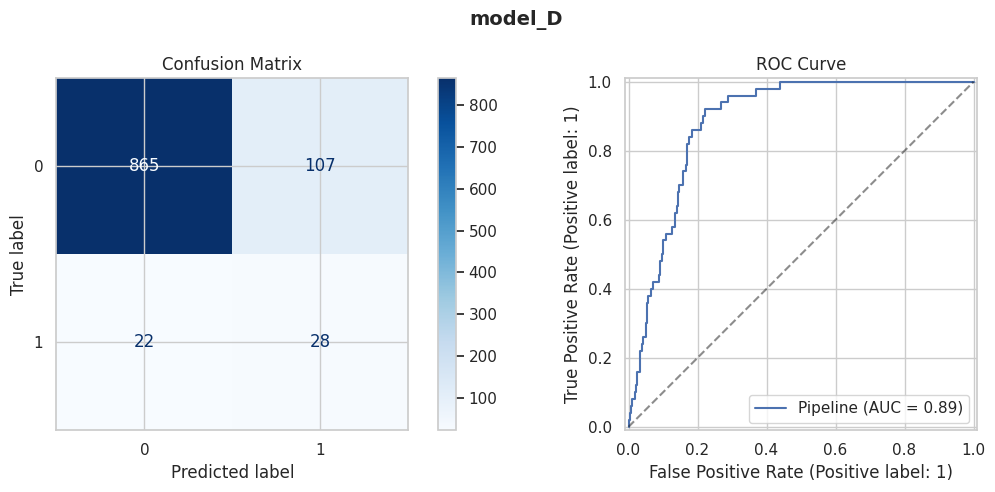

,model,accuracy,precision,recall,f1,roc_auc
0,model_D,0.873777,0.207407,0.56,0.302703,0.885000
1,model_A,0.869863,0.201439,0.56,0.296296,0.884733
2,model_C,0.755382,0.152778,0.88,0.260355,0.886420
3,model_B,0.731898,0.141026,0.88,0.243094,0.861667


In [4]:
def align_features_for_model(model, X: pd.DataFrame) -> pd.DataFrame:
    expected_features = getattr(model, "feature_names_", None)
    if not expected_features:
        return X

    X_aligned = X.copy()
    for col in expected_features:
        if col not in X_aligned.columns:
            X_aligned[col] = 0

    return X_aligned[list(expected_features)]


individual_metrics = []
for name, model in models.items():
    X_test_model = align_features_for_model(model, X_test)
    m = plot_full_evaluation(model, X_test_model, y_test, model_name=name)
    individual_metrics.append(m)

df_individual = compare_models(individual_metrics)
df_individual

## 3. Ensemble por Hard Voting

Modelos incluidos en el ensemble: ['model_A', 'model_B', 'model_D']
=== Votación mayoritaria (hard) ===
              precision    recall  f1-score   support

           0       0.98      0.88      0.93       972
           1       0.20      0.60      0.30        50

    accuracy                           0.87      1022
   macro avg       0.59      0.74      0.62      1022
weighted avg       0.94      0.87      0.90      1022



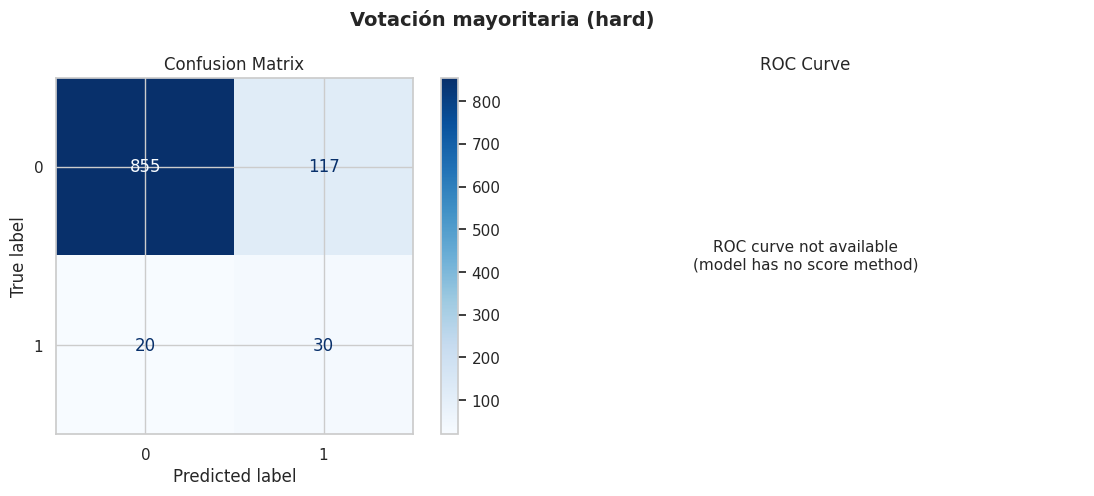

In [5]:
ensemble_estimators = [
    (name, model) for name, model in models.items() if name != "model_C"
]
print(f"Modelos incluidos en el ensemble: {[name for name, _ in ensemble_estimators]}")

hard_voting = VotingClassifier(
    estimators=ensemble_estimators,
    voting="hard",
)

hard_voting.fit(X_train, y_train)
hard_metrics = plot_full_evaluation(
    hard_voting,
    X_test,
    y_test,
    model_name="Votación mayoritaria (hard)",
)

## 4. Ensemble por Soft Voting

=== Votación suave (soft) ===
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       972
           1       0.21      0.16      0.18        50

    accuracy                           0.93      1022
   macro avg       0.58      0.56      0.57      1022
weighted avg       0.92      0.93      0.92      1022



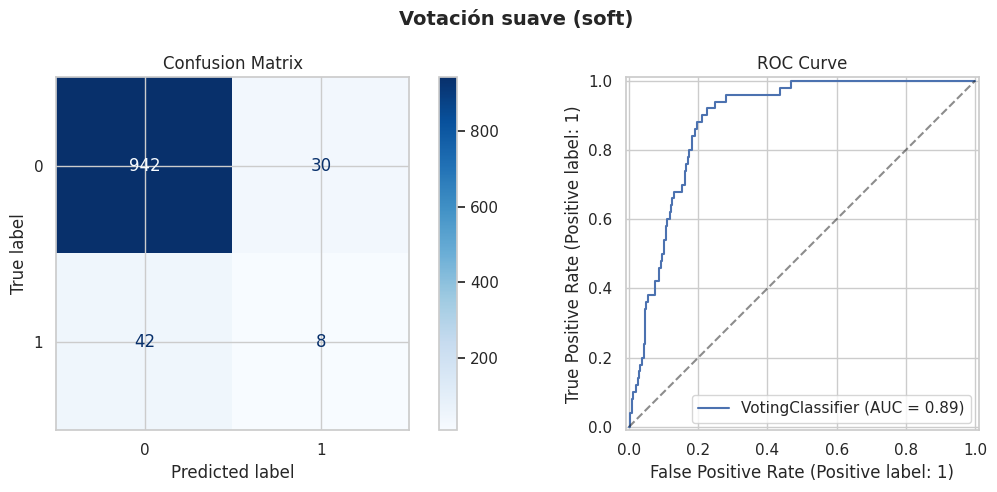

In [6]:
soft_voting = VotingClassifier(
    estimators=ensemble_estimators,
    voting="soft",
)

soft_voting.fit(X_train, y_train)
soft_metrics = plot_full_evaluation(
    soft_voting,
    X_test,
    y_test,
    model_name="Votación suave (soft)",
)

## 6. Ensemble por Stacking

Usa una Regresión Logística como meta-modelo sobre las predicciones de los modelos base.

=== Stacking (apilado) ===
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



/home/mmw/Documents/repos/AdM_TP/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mmw/Documents/repos/AdM_TP/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mmw/Documents/repos/AdM_TP/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

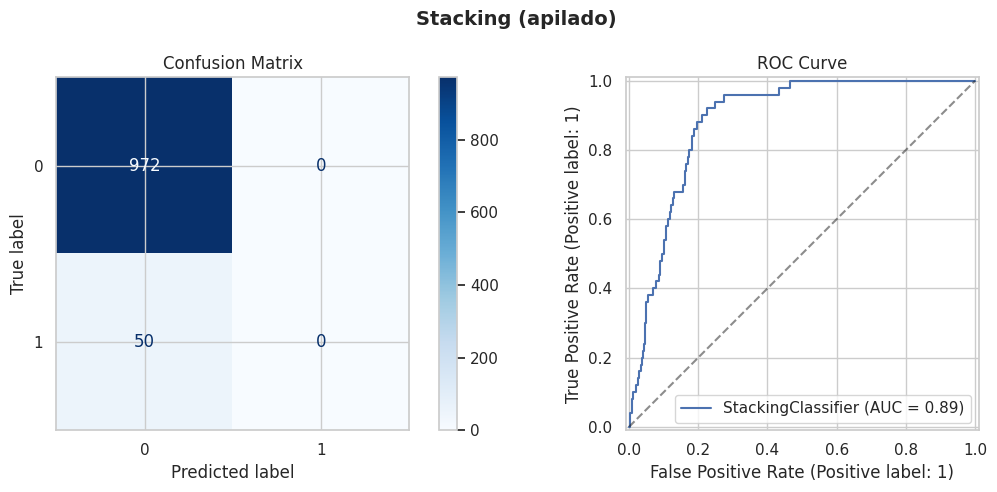

In [7]:
stacking = StackingClassifier(
    estimators=ensemble_estimators,
    final_estimator=LogisticRegression(random_state=13),
    cv=5,
    passthrough=False,
)

stacking.fit(X_train, y_train)
stacking_metrics = plot_full_evaluation(
    stacking,
    X_test,
    y_test,
    model_name="Stacking (apilado)",
)

## 7. Comparación: Todos los Modelos y Ensembles

In [8]:
all_metrics = individual_metrics + [
    hard_metrics,
    soft_metrics,
    stacking_metrics,
]
df_comparison = compare_models(all_metrics)
df_comparison

,model,accuracy,precision,recall,f1,roc_auc
0,Votación mayoritaria (hard),0.865949,0.204082,0.60,0.304569,NaN
1,model_D,0.873777,0.207407,0.56,0.302703,0.885000
2,model_A,0.869863,0.201439,0.56,0.296296,0.884733
3,model_C,0.755382,0.152778,0.88,0.260355,0.886420
4,model_B,0.731898,0.141026,0.88,0.243094,0.861667
5,Votación suave (soft),0.929550,0.210526,0.16,0.181818,0.885453
6,Stacking (apilado),0.951076,0.000000,0.00,0.000000,0.885658


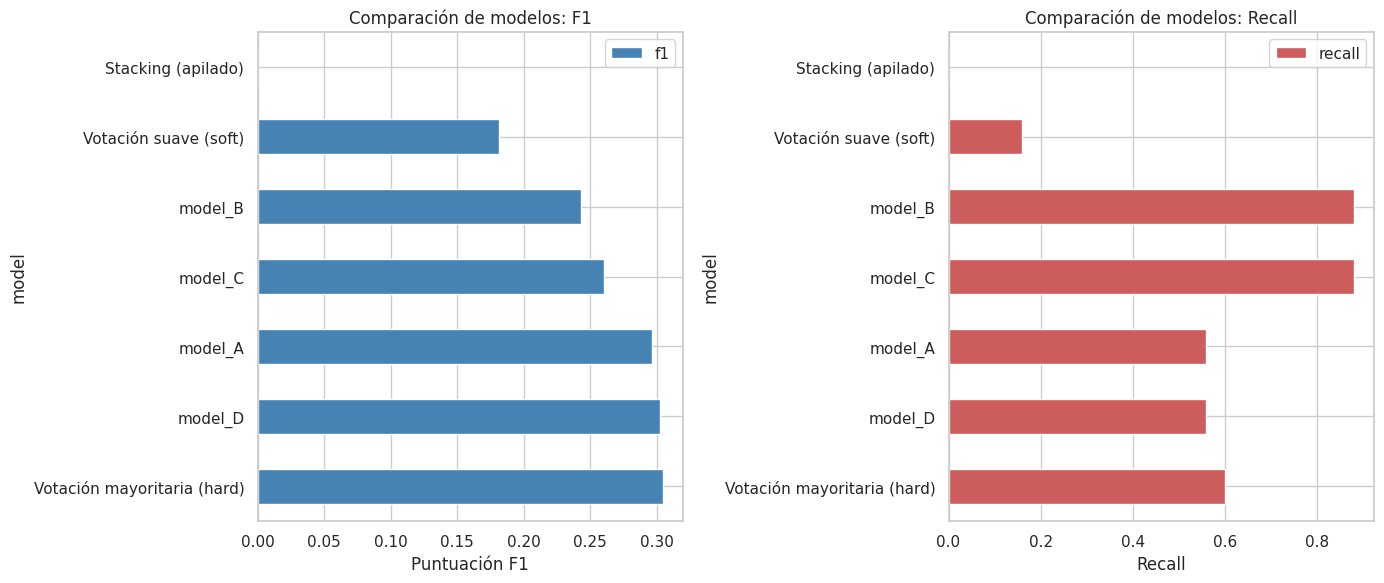

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# F1 Score
df_comparison.plot.barh(x="model", y="f1", ax=axes[0], color="steelblue")
axes[0].set_xlabel("Puntuación F1")
axes[0].set_title("Comparación de modelos: F1")

# Recall
df_comparison.plot.barh(x="model", y="recall", ax=axes[1], color="indianred")
axes[1].set_xlabel("Recall")
axes[1].set_title("Comparación de modelos: Recall")

plt.tight_layout()
plt.show()

## 8. Conclusiones

- Mejor estrategia de conjunto: elegir el modelo con mejor rendimiento en `df_comparison` priorizando `f1` y comprobando `recall` para la clase positiva (ictus).
- Análisis de aporte: comparar cada ensemble con `df_individual` para ver si la combinación mejora al mejor modelo individual.
- Recomendación final: elegir el modelo con el mejor equilibrio entre detección de ictus (recall) y falsos positivos (precision), apoyándose en ROC-AUC de forma secundaria.

## 9. Comparación Final: Mejor Ensemble vs Modelo C

In [10]:
ensemble_names = {
    "Votación mayoritaria (hard)",
    "Votación suave (soft)",
    "Stacking (apilado)",
}

best_ensemble = df_comparison[df_comparison["model"].isin(ensemble_names)].head(1)
model_c_metrics = df_comparison[df_comparison["model"] == "model_C"]

ensemble_vs_model_c = pd.concat([best_ensemble, model_c_metrics], ignore_index=True)
ensemble_vs_model_c

,model,accuracy,precision,recall,f1,roc_auc
0,Votación mayoritaria (hard),0.865949,0.204082,0.60,0.304569,NaN
1,model_C,0.755382,0.152778,0.88,0.260355,0.88642
